# Lösung – Aufgabenblatt 1
## Eindimensionale Analysis – Differentialrechnung 1

In [197]:
from sympy import *
import matplotlib.pyplot as plt
import numpy as np

x = symbols('x', real=True)

# Nice LaTeX display
init_printing(use_latex='mathjax')

---
## Aufgabe 1 – Rationale Funktion

**Gegeben:**
$$f(x)=\frac{1-x^2}{1+x^2}$$

### Methode: Quotientenregel

Die **Quotientenregel** lautet:
$$\left(\frac{u}{v}\right)' = \frac{u'v - uv'}{v^2}$$

**Schritt 1: Zähler und Nenner identifizieren**
$$u(x) = 1 - x^2, \qquad v(x) = 1 + x^2$$

**Schritt 2: Ableitungen bilden** (Potenzregel $\frac{d}{dx}x^n = nx^{n-1}$)
$$u'(x) = -2x, \qquad v'(x) = 2x$$

**Schritt 3: Einsetzen in die Quotientenregel**
$$f'(x) = \frac{(-2x)(1+x^2) - (1-x^2)(2x)}{(1+x^2)^2}$$

**Schritt 4: Zähler ausmultiplizieren**
$$= \frac{-2x - 2x^3 - 2x + 2x^3}{(1+x^2)^2}$$

**Schritt 5: Zusammenfassen** (die $\pm 2x^3$-Terme heben sich auf)
$$\boxed{f'(x) = \frac{-4x}{(1+x^2)^2}}$$

In [198]:
f1 = (1 - x**2) / (1 + x**2)
df1 = diff(f1, x)
df1.simplify()

  -4⋅x   
─────────
        2
⎛ 2    ⎞ 
⎝x  + 1⎠ 

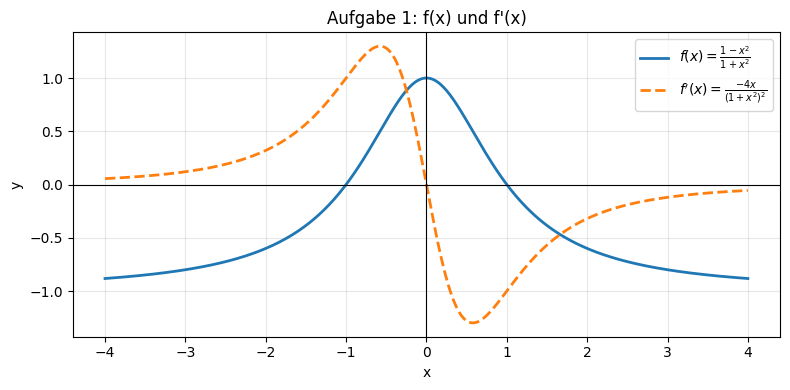

In [199]:
xs = np.linspace(-4, 4, 400)
f1_num  = (1 - xs**2) / (1 + xs**2)
df1_num = -4*xs / (1 + xs**2)**2

plt.figure(figsize=(8, 4))
plt.plot(xs, f1_num,  label=r'$f(x)=\frac{1-x^2}{1+x^2}$', lw=2)
plt.plot(xs, df1_num, label=r"$f'(x)=\frac{-4x}{(1+x^2)^2}$", lw=2, linestyle='--')
plt.axhline(0, color='k', linewidth=0.8)
plt.axvline(0, color='k', linewidth=0.8)
plt.title('Aufgabe 1: f(x) und f\'(x)')
plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

> **Beobachtung:** $f'(x) < 0$ für $x > 0$ und $f'(x) > 0$ für $x < 0$, d.h. $f$ hat ein Maximum bei $x=0$. Dies ist am Plot gut erkennbar.

---
## Aufgabe 2 – Wurzelfunktion

**Gegeben:**
$$f(x)=\sqrt{x^3-2x}$$

### Methode: Kettenregel

Die **Kettenregel** lautet:
$$\frac{d}{dx}[g(h(x))] = g'(h(x)) \cdot h'(x)$$

**Schritt 1: Funktion als Verkettung erkennen**

Schreibe $f(x) = (x^3 - 2x)^{1/2}$, also:
$$g(u) = \sqrt{u} = u^{1/2}, \qquad h(x) = x^3 - 2x$$

**Schritt 2: Äußere Ableitung**
$$g'(u) = \frac{1}{2}u^{-1/2} = \frac{1}{2\sqrt{u}}$$

**Schritt 3: Innere Ableitung**
$$h'(x) = 3x^2 - 2$$

**Schritt 4: Kettenregel anwenden**
$$f'(x) = \frac{1}{2\sqrt{x^3-2x}} \cdot (3x^2 - 2)$$

$$\boxed{f'(x) = \frac{3x^2-2}{2\sqrt{x^3-2x}}}$$

> **Definitionsbereich:** $f(x)$ ist nur definiert für $x^3 - 2x \geq 0$, d.h. $x(x^2-2) \geq 0$, also $x \in [-\sqrt{2},\,0]\cup[\sqrt{2},\infty)$.

In [200]:
f2 = sqrt(x**3 - 2*x)
df2 = diff(f2, x)
print("f'(x) = ", df2.simplify())

f'(x) =  (3*x**2 - 2)/(2*sqrt(x*(x**2 - 2)))


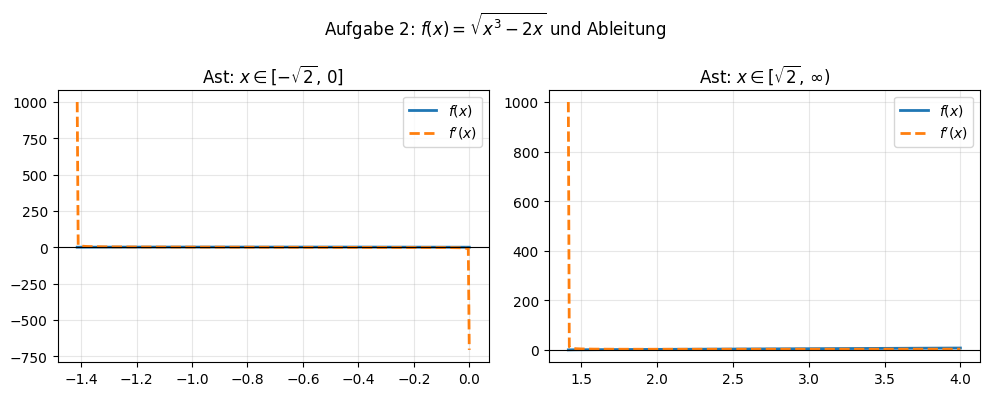

In [201]:
# Plot only on valid domain segments
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (a, b), title in zip(
        axes,
        [(-np.sqrt(2), 0), (np.sqrt(2), 4)],
        ['Ast: $x \\in [-\\sqrt{2},\\,0]$', 'Ast: $x \\in [\\sqrt{2},\\,\\infty)$']):
    xs = np.linspace(a + 1e-6, b - 1e-6, 400)
    ys  = np.sqrt(xs**3 - 2*xs)
    dys = (3*xs**2 - 2) / (2*np.sqrt(xs**3 - 2*xs))
    ax.plot(xs, ys,  label=r'$f(x)$', lw=2)
    ax.plot(xs, dys, label=r"$f'(x)$", lw=2, linestyle='--')
    ax.axhline(0, color='k', linewidth=0.8)
    ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)

fig.suptitle('Aufgabe 2: $f(x)=\\sqrt{x^3-2x}$ und Ableitung')
plt.tight_layout(); plt.show()

---
## Aufgabe 3 – Wurzelfunktion im Nenner

**Gegeben:**
$$f(x)=\frac{1}{\sqrt{x-1}}$$

### Methode: Umschreiben + Kettenregel

**Schritt 1: Potenzschreibweise**
$$f(x) = (x-1)^{-1/2}$$

**Schritt 2: Verkettung erkennen**
$$g(u) = u^{-1/2}, \qquad h(x) = x - 1$$

**Schritt 3: Äußere Ableitung** (Potenzregel)
$$g'(u) = -\frac{1}{2}u^{-3/2}$$

**Schritt 4: Innere Ableitung**
$$h'(x) = 1$$

**Schritt 5: Zusammensetzen**
$$f'(x) = -\frac{1}{2}(x-1)^{-3/2} \cdot 1 = -\frac{1}{2(x-1)^{3/2}}$$

$$\boxed{f'(x) = -\frac{1}{2\,(x-1)^{3/2}} = -\frac{1}{2\sqrt{(x-1)^3}}}$$

> **Definitionsbereich:** $f$ ist definiert für $x > 1$.

In [202]:
f3 = 1 / sqrt(x - 1)
df3 = diff(f3, x)
f3.simplify()

    1    
─────────
  _______
╲╱ x - 1 

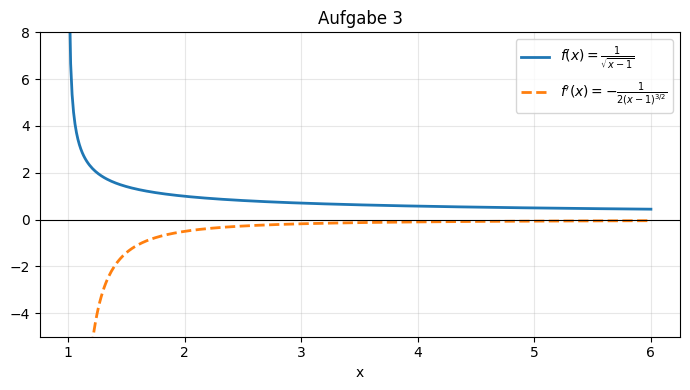

In [203]:
xs = np.linspace(1.01, 6, 400)
plt.figure(figsize=(7, 4))
plt.plot(xs, 1/np.sqrt(xs-1),              label=r'$f(x)=\frac{1}{\sqrt{x-1}}$', lw=2)
plt.plot(xs, -1/(2*(xs-1)**(3/2)),          label=r"$f'(x)=-\frac{1}{2(x-1)^{3/2}}$", lw=2, linestyle='--')
plt.axhline(0, color='k', linewidth=0.8)
plt.ylim(-5, 8)
plt.title('Aufgabe 3'); plt.xlabel('x'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Aufgabe 4 – Trigonometrische Funktionen

### Teil a)

**Gegeben:** $f(x)=\sin x\cos x$

### Methode: Produktregel

Die **Produktregel** lautet: $(u \cdot v)' = u'v + uv'$

**Schritt 1: Faktoren und Ableitungen**
$$u = \sin x \Rightarrow u' = \cos x, \qquad v = \cos x \Rightarrow v' = -\sin x$$

**Schritt 2: Einsetzen**
$$f'(x) = \cos x \cdot \cos x + \sin x \cdot (-\sin x) = \cos^2 x - \sin^2 x$$

**Schritt 3: Trigonometrische Identität anwenden**

Mit dem **Doppelwinkelgesetz** $\cos(2x) = \cos^2 x - \sin^2 x$:

$$\boxed{f'(x) = \cos(2x)}$$

> **Alternativ:** Man hätte zuerst $\sin x \cos x = \frac{1}{2}\sin(2x)$ vereinfachen können, dann $f'(x) = \frac{1}{2} \cdot 2\cos(2x) = \cos(2x)$.

In [204]:
f4a = sin(x)*cos(x)
df4a = diff(f4a, x)
print("f'(x) =         ", df4a)
print("vereinfacht:    ", trigsimp(df4a))

f'(x) =          -sin(x)**2 + cos(x)**2
vereinfacht:     cos(2*x)


### Teil b)

**Gegeben:** $f(x)=\sin^2 x$

### Methode: Kettenregel

**Schritt 1: Verkettung**
$$g(u) = u^2, \qquad h(x) = \sin x$$

**Schritt 2: Ableitungen**
$$g'(u) = 2u, \qquad h'(x) = \cos x$$

**Schritt 3: Kettenregel**
$$f'(x) = 2\sin x \cdot \cos x$$

**Schritt 4: Vereinfachung** (wieder Doppelwinkelgesetz $\sin(2x) = 2\sin x \cos x$)

$$\boxed{f'(x) = 2\sin x\cos x = \sin(2x)}$$

> **Konsistenzcheck:** Da $\sin^2 x = \frac{1-\cos(2x)}{2}$ (Halbwinkelformel), ergibt die direkte Ableitung ebenfalls $\frac{1}{2}\cdot 2\sin(2x) = \sin(2x)$. ✓

In [205]:
f4b = sin(x)**2
df4b = diff(f4b, x)
print("f'(x) =         ", df4b)
print("vereinfacht:    ", trigsimp(df4b))

f'(x) =          2*sin(x)*cos(x)
vereinfacht:     sin(2*x)


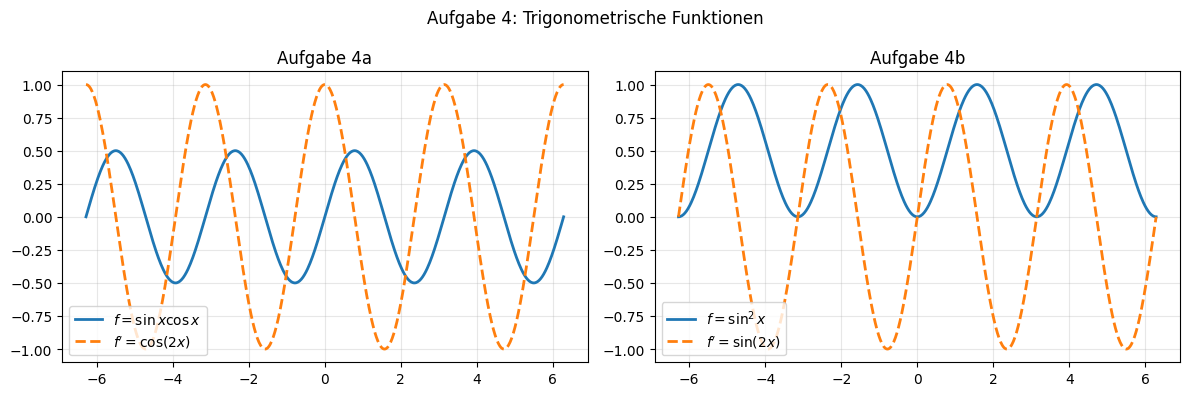

In [206]:
xs = np.linspace(-2*np.pi, 2*np.pi, 600)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 4a
axes[0].plot(xs, np.sin(xs)*np.cos(xs), label=r'$f=\sin x \cos x$', lw=2)
axes[0].plot(xs, np.cos(2*xs),          label=r"$f'=\cos(2x)$", lw=2, ls='--')
axes[0].set_title('Aufgabe 4a'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# 4b
axes[1].plot(xs, np.sin(xs)**2,  label=r'$f=\sin^2 x$', lw=2)
axes[1].plot(xs, np.sin(2*xs),   label=r"$f'=\sin(2x)$", lw=2, ls='--')
axes[1].set_title('Aufgabe 4b'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Aufgabe 4: Trigonometrische Funktionen')
plt.tight_layout(); plt.show()

---
## Aufgabe 5 – Weitere trigonometrische Funktionen

### Teil a)

**Gegeben:** $f(x)=\sin(x^2)$

### Methode: Kettenregel

**Schritt 1: Verkettung**
$$g(u) = \sin u, \qquad h(x) = x^2$$

**Schritt 2: Ableitungen**
$$g'(u) = \cos u, \qquad h'(x) = 2x$$

**Schritt 3: Kettenregel**
$$\boxed{f'(x) = \cos(x^2) \cdot 2x = 2x\cos(x^2)}$$

In [207]:
f5a = sin(x**2)
df5a = diff(f5a, x)
print("f'(x) = ", df5a)

f'(x) =  2*x*cos(x**2)


### Teil b)

**Gegeben:** $f(x)=\tan x\cdot\sin x$

### Methode: Produktregel

**Schritt 1: Faktoren und bekannte Ableitungen**
$$u = \tan x \Rightarrow u' = \frac{1}{\cos^2 x} = \sec^2 x$$
$$v = \sin x \Rightarrow v' = \cos x$$

**Schritt 2: Produktregel anwenden**
$$f'(x) = \frac{\sin x}{\cos^2 x} + \tan x \cdot \cos x$$

**Schritt 3: $\tan x = \frac{\sin x}{\cos x}$ einsetzen**
$$= \frac{\sin x}{\cos^2 x} + \frac{\sin x}{\cos x}\cdot\cos x = \frac{\sin x}{\cos^2 x} + \sin x$$

**Schritt 4: Zusammenfassen**
$$= \sin x\left(\frac{1}{\cos^2 x} + 1\right) = \sin x \cdot \frac{1 + \cos^2 x}{\cos^2 x}$$

$$\boxed{f'(x) = \frac{\sin x(1+\cos^2 x)}{\cos^2 x}}$$

In [208]:
f5b = tan(x)*sin(x)
df5b = diff(f5b, x)
print("f'(x) =         ", df5b)
print("vereinfacht:    ", trigsimp(df5b))
print("faktorisiert:   ", factor(df5b))

f'(x) =          (tan(x)**2 + 1)*sin(x) + cos(x)*tan(x)
vereinfacht:     (1 + cos(x)**(-2))*sin(x)
faktorisiert:    sin(x)*tan(x)**2 + sin(x) + cos(x)*tan(x)


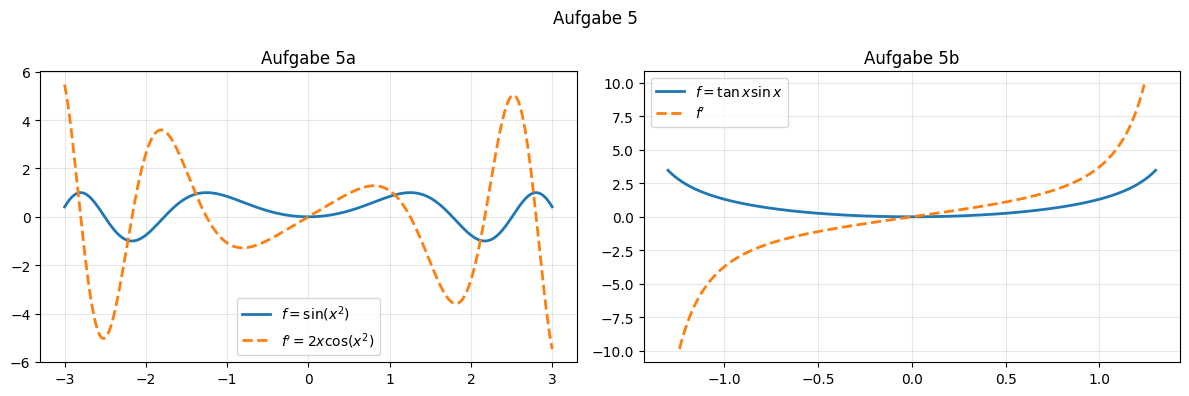

In [209]:
# Plot 5a and 5b
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

xs_a = np.linspace(-3, 3, 600)
axes[0].plot(xs_a, np.sin(xs_a**2),             label=r'$f=\sin(x^2)$', lw=2)
axes[0].plot(xs_a, 2*xs_a*np.cos(xs_a**2),      label=r"$f'=2x\cos(x^2)$", lw=2, ls='--')
axes[0].set_title('Aufgabe 5a'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# avoid singularities of tan
xs_b = np.linspace(-1.3, 1.3, 600)
with np.errstate(divide='ignore', invalid='ignore'):
    yf  = np.tan(xs_b)*np.sin(xs_b)
    ydf = np.sin(xs_b)*(1+np.cos(xs_b)**2)/np.cos(xs_b)**2
axes[1].plot(xs_b, np.where(np.abs(yf) < 10, yf, np.nan),   label=r'$f=\tan x\sin x$', lw=2)
axes[1].plot(xs_b, np.where(np.abs(ydf) < 10, ydf, np.nan), label=r"$f'$", lw=2, ls='--')
axes[1].set_title('Aufgabe 5b'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Aufgabe 5')
plt.tight_layout(); plt.show()

---
## Aufgabe 6 – Arkustangens mit Wurzel

**Gegeben:**
$$f(x) = \arctan\sqrt{x}$$

### Methode: Kettenregel (zweifach)

**Schritt 1: Verkettung erkennen**

Dies ist eine doppelte Verkettung: $f(x) = \arctan(\underbrace{x^{1/2}}_{h(x)})$

**Schritt 2: Bekannte Ableitung von $\arctan$**
$$\frac{d}{du}\arctan(u) = \frac{1}{1+u^2}$$

**Schritt 3: Innere Ableitung**
$$\frac{d}{dx}\sqrt{x} = \frac{1}{2\sqrt{x}}$$

**Schritt 4: Kettenregel anwenden**
$$f'(x) = \frac{1}{1+(\sqrt{x})^2} \cdot \frac{1}{2\sqrt{x}} = \frac{1}{1+x}\cdot\frac{1}{2\sqrt{x}}$$

$$\boxed{f'(x) = \frac{1}{2\sqrt{x}\,(1+x)}}$$

> **Definitionsbereich:** $f$ ist definiert für $x \geq 0$ (wegen $\sqrt{x}$), für $f'$ sogar nur $x > 0$.

In [210]:
f6 = atan(sqrt(x))
df6 = diff(f6, x)
print("f'(x) = ", df6.simplify())

f'(x) =  1/(2*sqrt(x)*(x + 1))


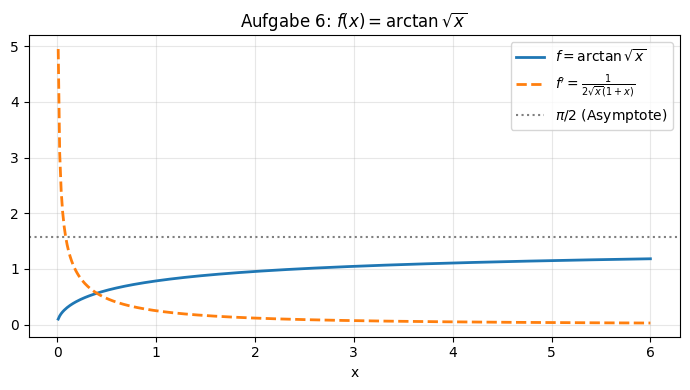

In [211]:
xs = np.linspace(0.01, 6, 400)
plt.figure(figsize=(7, 4))
plt.plot(xs, np.arctan(np.sqrt(xs)),             label=r'$f=\arctan\sqrt{x}$', lw=2)
plt.plot(xs, 1/(2*np.sqrt(xs)*(1+xs)),           label=r"$f'=\frac{1}{2\sqrt{x}(1+x)}$", lw=2, ls='--')
plt.axhline(np.pi/2, color='gray', ls=':', label=r'$\pi/2$ (Asymptote)')
plt.title('Aufgabe 6: $f(x) = \\arctan\\sqrt{x}$')
plt.xlabel('x'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Aufgabe 7 – Arkuskosinus mit Exponentialfunktion

**Gegeben:**
$$f(x) = \arccos(e^x)$$

### Methode: Kettenregel

**Schritt 1: Bekannte Ableitung von $\arccos$**
$$\frac{d}{du}\arccos(u) = -\frac{1}{\sqrt{1-u^2}}$$

**Schritt 2: Innere Ableitung**
$$\frac{d}{dx}e^x = e^x$$

**Schritt 3: Kettenregel**
$$f'(x) = -\frac{1}{\sqrt{1-(e^x)^2}} \cdot e^x$$

$$\boxed{f'(x) = -\frac{e^x}{\sqrt{1-e^{2x}}}}$$

> **Definitionsbereich:** Wir benötigen $|e^x| \leq 1$, also $e^x \leq 1$ (da $e^x > 0$), d.h. $x \leq 0$. Für $f'$ benötigen wir sogar $e^x < 1$, also $x < 0$.

In [212]:
f7 = acos(exp(x))
df7 = diff(f7, x)
print("f'(x) = ", df7.simplify())

f'(x) =  -exp(x)/sqrt(1 - exp(2*x))


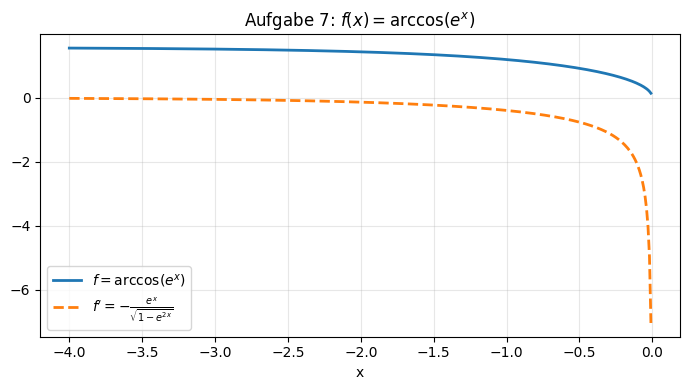

In [213]:
xs = np.linspace(-4, -0.01, 400)
plt.figure(figsize=(7, 4))
plt.plot(xs, np.arccos(np.exp(xs)),                   label=r'$f=\arccos(e^x)$', lw=2)
plt.plot(xs, -np.exp(xs)/np.sqrt(1-np.exp(2*xs)),     label=r"$f'=-\frac{e^x}{\sqrt{1-e^{2x}}}$", lw=2, ls='--')
plt.title('Aufgabe 7: $f(x) = \\arccos(e^x)$')
plt.xlabel('x'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Aufgabe 8 – Kurvendiskussion

**Gegeben:**
$$f(x) = x^3 - 3x$$

Wir diskutieren vollständig: **Plot, Nullstellen, Extrema, Monotonie, Wendepunkte, Krümmung, Konvergenz**.

---
### 8.1 Ableitungen

$$f(x) = x^3 - 3x$$
$$f'(x) = 3x^2 - 3 = 3(x^2-1) = 3(x-1)(x+1)$$
$$f''(x) = 6x$$
$$f'''(x) = 6 \neq 0$$

---
### 8.2 Nullstellen

$$f(x) = 0 \Leftrightarrow x^3 - 3x = 0 \Leftrightarrow x(x^2-3) = 0$$

$$\boxed{x_1 = -\sqrt{3},\quad x_2 = 0,\quad x_3 = \sqrt{3}}$$

---
### 8.3 Extrema

**Kritische Punkte:** $f'(x) = 0 \Rightarrow 3(x-1)(x+1) = 0 \Rightarrow x = \pm 1$

**Klassifikation via $f''$:**

| $x$ | $f''(x)$ | Typ | $f(x)$ |
|-----|----------|-----|--------|
| $-1$ | $f''(-1) = -6 < 0$ | **Lokales Maximum** | $f(-1) = -1+3 = 2$ |
| $+1$ | $f''(+1) = +6 > 0$ | **Lokales Minimum** | $f(1) = 1-3 = -2$ |

---
### 8.4 Monotonie

Vorzeichen von $f'(x) = 3(x-1)(x+1)$:

| Intervall | Vorzeichen $f'$ | Monotonie |
|-----------|----------------|-----------|
| $(-\infty,-1)$ | $+$ | **streng monoton steigend** |
| $(-1,+1)$ | $-$ | **streng monoton fallend** |
| $(+1,+\infty)$ | $+$ | **streng monoton steigend** |

---
### 8.5 Wendepunkte

**Notwendige Bedingung:** $f''(x) = 0 \Rightarrow 6x = 0 \Rightarrow x = 0$

**Hinreichende Bedingung:** $f'''(0) = 6 \neq 0$ → **Wendepunkt** bei $x=0$

$$W = (0,\, f(0)) = (0, 0)$$

Die Wendetangente hat die Steigung $f'(0) = -3$, also:
$$t_W(x) = -3x$$

---
### 8.6 Krümmungsverhalten

| Intervall | Vorzeichen $f''$ | Krümmung |
|-----------|-----------------|----------|
| $(-\infty, 0)$ | $f'' < 0$ | **konkav** (linksgekrümmt) |
| $(0, +\infty)$ | $f'' > 0$ | **konvex** (rechtsgekrümmt) |

---
### 8.7 Konvergenzverhalten

Da $f$ ein Polynom 3. Grades mit positivem Leitkoeffizient:
$$\lim_{x \to +\infty} f(x) = +\infty, \qquad \lim_{x \to -\infty} f(x) = -\infty$$

Es gibt **keine Asymptoten**.

In [214]:
f8 = x**3 - 3*x
df8   = diff(f8, x)
ddf8  = diff(df8, x)
dddf8 = diff(ddf8, x)

zeros    = solve(f8, x)
extrema  = solve(df8, x)
inflect  = solve(ddf8, x)

print("f(x)   = ", f8)
print("f'(x)  = ", df8)
print("f''(x) = ", ddf8)
print()
print("Nullstellen:  ", zeros)
print("Extremstellen:", [(p, f8.subs(x,p)) for p in extrema])
print("Wendepunkte:  ", [(p, f8.subs(x,p)) for p in inflect])

f(x)   =  x**3 - 3*x
f'(x)  =  3*x**2 - 3
f''(x) =  6*x

Nullstellen:   [0, -sqrt(3), sqrt(3)]
Extremstellen: [(-1, 2), (1, -2)]
Wendepunkte:   [(0, 0)]


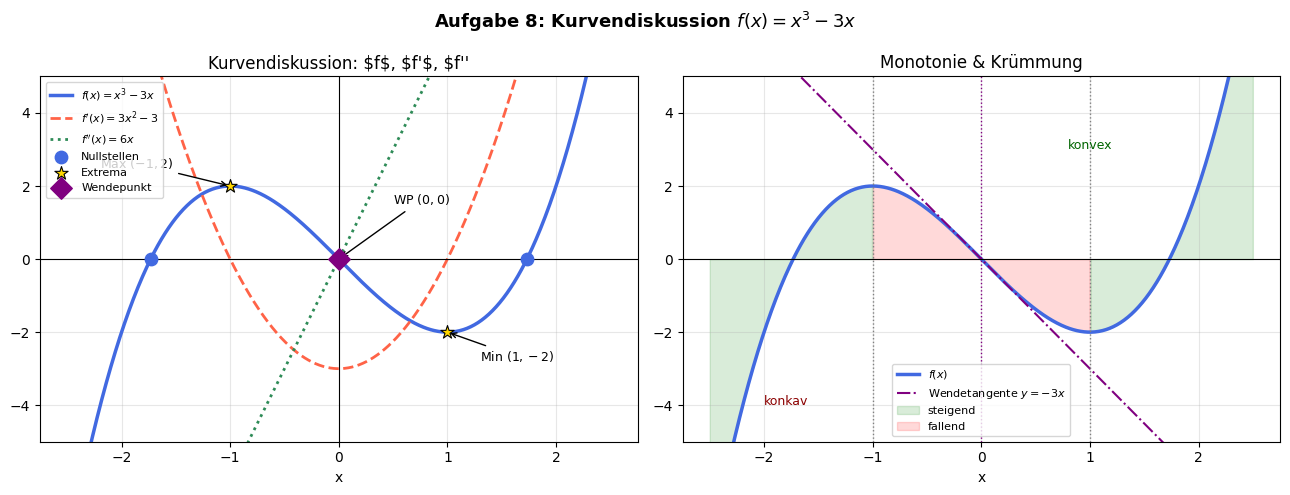

In [215]:
xs  = np.linspace(-2.5, 2.5, 600)
yf  = xs**3 - 3*xs
yd  = 3*xs**2 - 3
ydd = 6*xs
yt  = -3*xs   # Wendetangente

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: f, f', f'' ---
ax = axes[0]
ax.plot(xs, yf,  label=r'$f(x)=x^3-3x$', lw=2.5, color='royalblue')
ax.plot(xs, yd,  label=r"$f'(x)=3x^2-3$", lw=2, color='tomato', ls='--')
ax.plot(xs, ydd, label=r"$f''(x)=6x$", lw=2, color='seagreen', ls=':')

# Mark special points
ax.scatter([-np.sqrt(3), 0, np.sqrt(3)],
           [0, 0, 0], s=80, zorder=5, color='royalblue', label='Nullstellen')
ax.scatter([-1, 1], [2, -2], s=100, marker='*', zorder=5,
           color='gold', edgecolors='k', linewidths=0.8, label='Extrema')
ax.scatter([0], [0], s=120, marker='D', zorder=5,
           color='purple', label='Wendepunkt')

ax.axhline(0, color='k', lw=0.8)
ax.axvline(0, color='k', lw=0.8)

# Annotations
ax.annotate('Max $(-1,2)$', xy=(-1, 2),  xytext=(-2.2, 2.5),
            arrowprops=dict(arrowstyle='->', color='k'), fontsize=9)
ax.annotate('Min $(1,-2)$', xy=(1, -2),  xytext=(1.3, -2.8),
            arrowprops=dict(arrowstyle='->', color='k'), fontsize=9)
ax.annotate('WP $(0,0)$',   xy=(0, 0),   xytext=(0.5, 1.5),
            arrowprops=dict(arrowstyle='->', color='k'), fontsize=9)

ax.set_title('Kurvendiskussion: $f$, $f\'$, $f\'\'')
ax.set_xlabel('x'); ax.set_ylim(-5, 5)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# --- Right: Monotonie & Krümmung with shading ---
ax2 = axes[1]
ax2.plot(xs, yf, lw=2.5, color='royalblue', label=r'$f(x)$')
ax2.plot(xs, yt, lw=1.5, color='purple', ls='-.', label='Wendetangente $y=-3x$')

# Shade monotone regions
ax2.fill_between(xs, yf, where=(xs < -1),          alpha=0.15, color='green',  label='steigend')
ax2.fill_between(xs, yf, where=((xs>-1)&(xs<1)),   alpha=0.15, color='red',    label='fallend')
ax2.fill_between(xs, yf, where=(xs > 1),            alpha=0.15, color='green')

ax2.axvline(-1, color='gray', ls=':', lw=1)
ax2.axvline( 1, color='gray', ls=':', lw=1)
ax2.axvline( 0, color='purple', ls=':', lw=1)
ax2.axhline( 0, color='k', lw=0.8)

ax2.text(-2, -4,   'konkav', fontsize=9, color='darkred')
ax2.text( 0.8, 3,  'konvex', fontsize=9, color='darkgreen')

ax2.set_title('Monotonie & Krümmung')
ax2.set_xlabel('x'); ax2.set_ylim(-5, 5)
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.suptitle('Aufgabe 8: Kurvendiskussion $f(x)=x^3-3x$', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### Zusammenfassung – Aufgabe 8

| Eigenschaft | Ergebnis |
|------------|----------|
| **Nullstellen** | $x = -\sqrt{3},\; 0,\; \sqrt{3}$ |
| **Lokales Maximum** | $(-1,\; 2)$ |
| **Lokales Minimum** | $(1,\; -2)$ |
| **Monoton steigend** | $(-\infty,-1)\cup(1,\infty)$ |
| **Monoton fallend** | $(-1,1)$ |
| **Wendepunkt** | $(0,\; 0)$, Wendetangente $y=-3x$ |
| **Konkav** | $(-\infty, 0)$ |
| **Konvex** | $(0, \infty)$ |
| **Asymptoten** | keine (Polynom) |
| **Konvergenz** | $f(x)\to\pm\infty$ für $x\to\pm\infty$ |